In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
from Levenshtein import distance

In [8]:
def value_iteration(T, R, gamma, delta_threshold):
    n_states = R.shape[0]
    n_actions = T.shape[2]
    V = np.zeros((n_states))
    Q = np.zeros((n_states, n_actions))
    value_sums = [0]
    delta = np.inf
    iter = 0
    while delta > delta_threshold and iter < 1000:
        delta = 0
        for s in range(n_states):
            deltas_per_action = np.zeros((n_actions))
            for a in range(n_actions):
                Q[s, a] = 0
                for s_prime in range(n_states):
                    Q[s, a] += T[s, s_prime, a] * (R[s] + gamma * V[s_prime])
                deltas_per_action[a] = Q[s, a] - V[s]
            delta = np.maximum(delta, deltas_per_action.max())
            V[s] = Q[s, :].max()
        iter += 1
        value_sums.append(V.sum() / n_states)
        #print(Q)
    print(iter)
    #print(V)
    #print(Q)
    return value_sums

In [9]:
pos = np.genfromtxt("datasets/HC11/position_mm.txt")
spikes = np.genfromtxt("datasets/HC11/spikes_ms.txt")

cellindex = np.array([0,  40,  47,  45,  44,  41,  52,  85,  30, 109,  87,  73,   7,
        61,  64,  90,  10, 106,  25, 111,  96, 114,  51,  42,  98,   1,
        33, 104, 116,   8,  23,  79,   5,  36,  20,  53,  99,  83,  16,
        24,  78,  43,  22,   3,  12,  29,  84,   9,  19,  18,  57, 100,
       118,  65,  38,  67, 102,  35, 112,  94,   6,  66,  69, 105, 101,
        74, 113, 117,  80,  60,  21,  15,  58, 110,  28,  34,  77,  81,
       115,  55,  91,  86,  76,  27,  97,  89, 119,  75,  26,  17,  95,
        93,  31,  46,  54,  14,  88,  62,   2,  11,  56,  68,  48, 108,
        63,  13,  49, 103,  72,  59,  70,  37,  39,  50,  82,  71, 120,
        32,  92,   4, 107])

tmin = 18310
tmax = 18325

ii_spikes = np.flatnonzero((spikes[:,0] > tmin) & (spikes[:,0] < tmax))
sp = spikes[ii_spikes,:]

ii_pos = np.flatnonzero((pos[:,0] > tmin) & (pos[:,0] < tmax))
tx = pos[ii_pos,:]

/var/folders/jw/d5_trdxs6d10y2g48wcnb0880000gn/T/ipykernel_70069/1614044372.py:24: RuntimeWarning: invalid value encountered in divide
  act_mean_spike_time /= act_spike_count


Text(0.5, 0, 'time (s)')

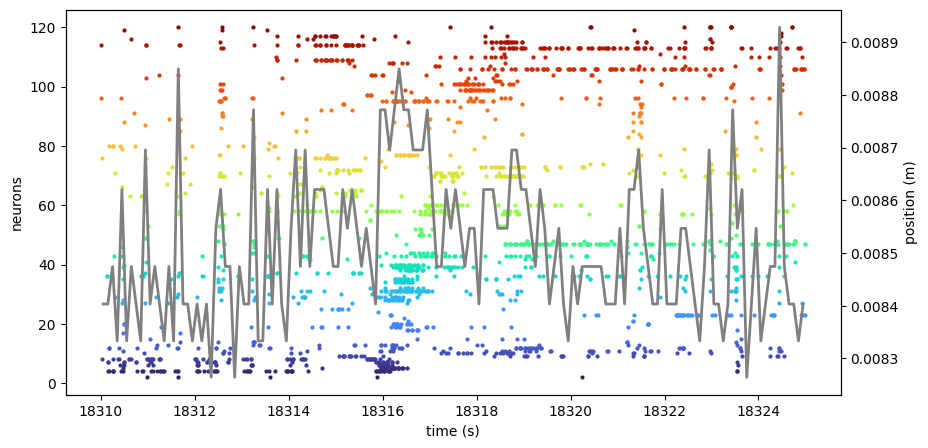

In [10]:

n_cell = len(cellindex)
n_spike = sp.shape[0]

window_width_s = 0.1
window_step_s = 0.1
replay_scores = []
window_midpoints = []

act_window_start = tmin
act_window_end = act_window_start + window_width_s

while act_window_end <= tmax:
    act_spike_count = np.zeros((n_cell))
    act_mean_spike_time = np.zeros((n_cell))

    for spike_idx in range(n_spike):
        spike_time = sp[spike_idx, 0]
        spike_cell = int(sp[spike_idx, 1])
        if spike_time >= act_window_start and spike_time < act_window_end:
            act_spike_count[spike_cell] += 1
            act_mean_spike_time[spike_cell] += spike_time
        #elif spike_time >= act_window_end:
        #    break
    act_mean_spike_time /= act_spike_count
    #print(act_mean_spike_time)
    cells_spiked = np.flatnonzero(act_spike_count)
    ordering_indices = np.argsort(act_mean_spike_time[cells_spiked])
    codeword = cells_spiked[ordering_indices]
    replay_score = 1. / distance(codeword, cellindex)
    replay_scores.append(replay_score)
    window_midpoints.append(act_window_start + (act_window_end - act_window_start) / 2)
    act_window_start += window_step_s
    act_window_end += window_step_s
    
cmap = mpl.colormaps['turbo']
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax2.plot(window_midpoints, replay_scores, c='grey', zorder=1, linewidth=2)

for i_cell in np.arange(121):
    idx = np.flatnonzero(sp[:,1] == i_cell)
    if (len(idx) > 0):
        jj = np.flatnonzero(cellindex == i_cell)
        ax.scatter(sp[idx,0], np.ones(len(idx)) * jj, s=4, c=cmap(jj/121), zorder=2)
        
        # ax.scatter(sp[idx,0], np.ones(len(idx)) * i_cell, s=4, c='k')
ax2.set_ylabel('position (m)')
ax.set_ylabel('neurons')
ax.set_xlabel('time (s)')